In [49]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
#from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import  GradientBoostingRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [50]:
dfk = pd.read_csv("data/king_ country_ houses_aa.csv")


2. Explore the data to understand its structure — features, target variable, shape, and data types.
3. Clean the dataset (handle duplicates, missing values, etc.).
4. Split the dataset into features (X) and target (y).

In [52]:
dfkX = dfk[dfk.columns.drop('date')]

In [53]:
y = dfkX.price
X = dfkX[dfkX.columns.drop('price')]


#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
train_X, test_X, train_y, test_y = train_test_split(X, y, 
                                                    test_size = 0.25, 
                                                    random_state = 42)

GradientBoostingRegressor builds an additive model in a forward stage-wise fashion; it allows for the optimization of arbitrary differentiable loss functions. In each stage a regression tree is fit on the negative gradient of the given loss function.

In [54]:
#GradientBoostingRegressor
gbr = GradientBoostingRegressor(loss='absolute_error',
                                learning_rate=0.1,
                                n_estimators=300,
                                max_depth = 1, 
                                random_state = 42,
                                max_features = 5)

gbr.fit(train_X, train_y)

pred_y = gbr.predict(train_X)
print("#" * 23 + "GradientBoostingRegressor")
print("#" * 23 + "Train" + "#" * 23 )
trmse = mean_squared_error(train_y, pred_y)** (1 / 2)
train_mae = mean_absolute_error(train_y, pred_y)
tr2 = r2_score(train_y, pred_y)
print(f"Root Mean Squared Error: {trmse:.2f}") 
print('Mean Absolute Error    : {:.2f}'.format(train_mae))
print(f"R-squared Score        : {tr2:.2f}")

print("#" * 23 + "Test"  + "#" * 23)
pred_y = gbr.predict(test_X)
test_rmse = mean_squared_error(test_y, pred_y) ** (1 / 2)
test_mae = mean_absolute_error(test_y, pred_y)
r2 = r2_score(test_y, pred_y)

print('Root Mean Square Error: {:.2f}'.format(test_rmse))
print('Mean Absolute Error   : {:.2f}'.format(test_mae))
print(f"R² Score             : {r2:.3f}")
print(f"R² Score    diff      : {tr2-r2:.3f}")

#######################GradientBoostingRegressor
#######################Train#######################
Root Mean Squared Error: 197575.62
Mean Absolute Error    : 95610.02
R-squared Score        : 0.70
#######################Test#######################
Root Mean Square Error: 212414.77
Mean Absolute Error   : 101952.89
R² Score             : 0.698
R² Score    diff      : 0.001


In [29]:
#AdaBoostRegressor
"""base_estimator = DecisionTreeRegressor(max_depth=4, random_state=42)
model = AdaBoostRegressor(
    estimator=base_estimator,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

model.fit(train_X, train_y)

y_pred = model.predict(test_X)
mae = mean_absolute_error(test_y, y_pred)
r2 = r2_score(test_y, y_pred)

print(f"Mean Absolute Error: {mae:.3f}")
print(f"R² Score: {r2:.3f}")

cell_output: = "Mean Absolute Error: 123633.155; R² Score: 0.765"
"""

'base_estimator = DecisionTreeRegressor(max_depth=4, random_state=42)\nmodel = AdaBoostRegressor(\n    estimator=base_estimator,\n    n_estimators=100,\n    learning_rate=0.1,\n    random_state=42\n)\n\nmodel.fit(train_X, train_y)\n\ny_pred = model.predict(test_X)\nmae = mean_absolute_error(test_y, y_pred)\nr2 = r2_score(test_y, y_pred)\n\nprint(f"Mean Absolute Error: {mae:.3f}")\nprint(f"R² Score: {r2:.3f}")\n\ncell_output: = "Mean Absolute Error: 123633.155; R² Score: 0.765"\n'

XGBoost builds one tree for each class and the trees for each class are called a “group” of trees, so output dimension may change due to used model. Internally, XGBoost attempts to extract the categories from the dataframe inputs. For inference (predict), the re-coding happens on the fly and there’s no data copy.

In [55]:
#xGBoostRegressor
import xgboost as xgb

xgb_reg = xgb.XGBRegressor()
xgb_reg.fit(train_X, train_y)

y_pred = xgb_reg.predict(train_X)

print("#" * 23 + "XGBRegressor")
print("#" * 23 + "Train" + "#" * 23 )
trmse = mean_squared_error(train_y, y_pred)** (1 / 2)
train_mae = mean_absolute_error(train_y, y_pred)
tr2 = r2_score(train_y, y_pred)


print(f"Root Mean Squared Error: {trmse:.2f}") 
print('Mean Absolute Error    : {:.2f}'.format(train_mae))
print(f"R-squared Score       : {tr2:.2f}")

print("#" * 23 + "Test"  + "#" * 23 )
y_pred = xgb_reg.predict(test_X)
rmse = mean_squared_error(test_y, y_pred)** (1 / 2)
test_mae = mean_absolute_error(test_y, y_pred)
r2 = r2_score(test_y, y_pred)
print(f"Root Mean Squared Error: {rmse:.2f}") 
print('Mean Absolute Error    : {:.2f}'.format(test_mae))
print(f"R-squared Score        : {r2:.2f}")
print(f"R² Score    diff       : {tr2-r2:.3f}")

#######################XGBRegressor
#######################Train#######################
Root Mean Squared Error: 54988.57
Mean Absolute Error    : 39211.03
R-squared Score       : 0.98
#######################Test#######################
Root Mean Squared Error: 146876.36
Mean Absolute Error    : 73370.93
R-squared Score        : 0.86
R² Score    diff       : 0.121


PART II
### MODEL IMPROVEMENTS ###
hyper params adjusting




In [56]:
dfkX = pd.read_csv("data/king_county_clean.csv")
y = dfkX.log_price
X = dfkX[dfkX.columns.drop('log_price')]


#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
train_X, test_X, train_y, test_y = train_test_split(X, y, 
                                                    test_size = 0.25, 
                                                    random_state = 42)

## Hyper Param List

In [57]:
param_grid = {
    # 1. Modellkomplexität & Baumstruktur
    'max_depth': [3, 5, 6, 8],             # Tiefe der Bäume (Standard: 6). Größer = komplexer, aber Overfitting-Gefahr
    'min_child_weight': [1, 3, 5, 7],      # Mindestsumme der Instanzgewichte in einem Blatt. Höher = konservativer
    'gamma': [0, 0.1, 0.2, 0.4],           # Mindest-Loss-Reduktion für einen Split. Höher = konservativer

    # 2. Robustheit & Zufälligkeit (Regularisierung gegen Overfitting)
    'subsample': [0.7, 0.8, 0.9, 1.0],     # Anteil der Datenzeilen pro Baum
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0], # Anteil der Features (Spalten) pro Baum

    # 3. Lernrate & Boosting-Geschwindigkeit
    'learning_rate': [0.01, 0.05, 0.1, 0.2], # Schrittweite (eta). Niedriger ist besser, braucht aber mehr Bäume
    'n_estimators': [100, 300, 500, 1000],  # Anzahl der Bäume (Bäume)

    # 4. Regularisierungsterme (L1 und L2)
    'reg_alpha': [0, 0.1, 1, 10],          # L1-Regularisierung (Lasso-Effekt auf Feature-Weights)
    'reg_lambda': [1, 2, 5, 10]            # L2-Regularisierung (Ridge-Effekt, Standard: 1)
}

learning_rate vs. n_estimators

For the model to converge properly, either the learning rate or the number of estimators must be sufficiently high.

Strat_1: starting with high l_rate  ~ 0.1-0.05 and 600 trees. Then decrease l_rate and increase trees.

In [58]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

train_X, test_X, train_y, test_y = train_test_split(X, y, 
                                                    test_size = 0.25, 
                                                    random_state = 42)


# 1. Basis-Modell definieren
xgb = XGBRegressor(
    objective='reg:squarederror', 
    random_state=42, 
    n_jobs=-1  # Nutzt alle CPU-Kerne für die parallele Berechnung
)

# 2. Die Suche konfigurieren
# Wir nutzen 5-fache Kreuzvalidierung (cv=5) und testen 50 zufällige Kombinationen (n_iter=50)
xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,  # Dein vorhin definiertes Parameter-Grid
    n_iter=50,                       # Anzahl der zufällig gezogenen Parameter-Kombinationen
    scoring='neg_mean_squared_error',# Wir optimieren auf den kleinsten MSE (als negativer Wert in sklearn)
    cv=5,                            # 5-Fold Cross Validation
    random_state=42,
    n_jobs=-1,
    verbose=2                        # Zeigt dir live den Fortschritt der Berechnung an
)

# 3. Suche auf den (skalierten/vorbereiteten) Trainingsdaten starten
# Wichtig: y_train sollte bereits die log-transformierten Preise enthalten (log_price)!
xgb_search.fit(train_X, train_y)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.6, 0.7, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,n_iter,50
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [61]:
best_xgb_model = xgb_search.best_estimator_

log_predictions = best_xgb_model.predict(test_X)
import json

# 1. Parameter schön einrücken
print("=" * 40)
print("BEST TUNING-PARAMS")
print("=" * 40)
print(json.dumps(xgb_search.best_params_, indent=4))
print("=" * 40)



BEST TUNING-PARAMS
{
    "subsample": 0.7,
    "reg_lambda": 5,
    "reg_alpha": 0.1,
    "n_estimators": 300,
    "min_child_weight": 7,
    "max_depth": 6,
    "learning_rate": 0.1,
    "gamma": 0.1,
    "colsample_bytree": 1.0
}


In [60]:
y_pred = best_xgb_model.predict(train_X)

print("#" * 23 + "XGBRegressor")
print("#" * 23 + "Train" + "#" * 23 )
trmse = mean_squared_error(train_y, y_pred)** (1 / 2)
train_mae = mean_absolute_error(train_y, y_pred)
tr2 = r2_score(train_y, y_pred)


print(f"Root Mean Squared Error: {trmse:.2f}") 
print('Mean Absolute Error    : {:.2f}'.format(train_mae))
print(f"R-squared Score       : {tr2:.2f}")

print("#" * 23 + "Test"  + "#" * 23 )
y_pred = best_xgb_model.predict(test_X)
rmse = mean_squared_error(test_y, y_pred)** (1 / 2)
test_mae = mean_absolute_error(test_y, y_pred)
r2 = r2_score(test_y, y_pred)
print(f"Root Mean Squared Error: {rmse:.2f}") 
print('Mean Absolute Error    : {:.2f}'.format(test_mae))
print(f"R-squared Score        : {r2:.2f}")
print(f"R² Score    diff       : {tr2-r2:.3f}")

#######################XGBRegressor
#######################Train#######################
Root Mean Squared Error: 0.13
Mean Absolute Error    : 0.10
R-squared Score       : 0.94
#######################Test#######################
Root Mean Squared Error: 0.16
Mean Absolute Error    : 0.12
R-squared Score        : 0.90
R² Score    diff       : 0.033


comparing computed params to default params:

 computed: {

    "subsample": 0.7,

    "reg_lambda": 5,

    "reg_alpha": 0.1,

    "n_estimators": 300,

    "min_child_weight": 7,

    "max_depth": 6,

    "learning_rate": 0.1,

    "gamma": 0.1,

    "colsample_bytree": 1.0

}
default:

{

    "subsample": 1,

    "reg_lambda": 1,

    "reg_alpha": 0.0,

    "n_estimators": 100,

    "min_child_weight": 1,

    "max_depth": 6, (same)

    "learning_rate": 0.3,

    "gamma": 0.0,

    "colsample_bytree": 1.0 (same)
}



Discussion: Slower Learning: A smaller learning rate ensures steady learning and prevents overshooting, balanced out by building 300 trees instead of 100. 

Outlier Immunity: Each tree only sees 70% of the data, adding randomness that prevents the model from obsessing over extreme luxury outliers.

Full Feature Access: Every tree can use all available data columns, which fits the compact King County dataset perfectly.

Safe Depth: Maximum tree depth is kept at the standard setting of 6 to stop the model from memorizing training data too closely. 

High Thresholds: Stricter splitting rules prevent tiny, hyper-specific branches for individual houses. 

Strict Loss Control: A split must noticeably reduce the overall error; unimportant splits are blocked completely.

Smoother Predictions: L2 regularization is multiplied by 5 to gently push feature weights down and keep predictions stable. 

Feature Sparsity: A touch of L1 regularization neutralizes the impact of irrelevant or highly overlapping data columns. 

It's supposed to be more robust, whilst the R**2 score is about the same as in default.

### most influential features

In [62]:

feature_names = train_X.columns

importances = best_xgb_model.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'IMPORTANCE': importances
}).sort_values(by='IMPORTANCE', ascending=False)
print("=" * 45)
print(" MOST IMPORTANT FEATURES OF MY XGBOOST-MODEL")
print("=" * 45)
print(feature_imp_df.to_string(index=False))
print("=" * 45)

 MOST IMPORTANT FEATURES OF MY XGBOOST-MODEL
            Feature  IMPORTANCE
              grade    0.455421
        sqft_living    0.170088
                lat    0.127766
               view    0.037316
         waterfront    0.032863
      sqft_living15    0.027730
    dist_to_seattle    0.025672
          bathrooms    0.012072
        age_at_sale    0.011448
               long    0.010945
          sale_year    0.010756
          condition    0.010116
         sqft_above    0.009692
           sqft_lot    0.009603
           yr_built    0.009232
         sqft_lot15    0.008996
            zipcode    0.008188
       yr_renovated    0.006904
living_to_lot_ratio    0.004330
           bedrooms    0.003718
             floors    0.003572
      sqft_basement    0.003571


These can be compared to the strongest values in (spearman) correlation matrix:
 
STR. SPEARMAN CORR
 ------------
grade                     :  0.658

sqft_living               :  0.644

sqft_living15             :  0.572

sqft_above                :  0.542

bathrooms                 :  0.497

lat                       :  0.456

bedrooms                  :  0.345

floors                    :  0.322

view                      :  0.294

...

<Figure size 1000x800 with 0 Axes>

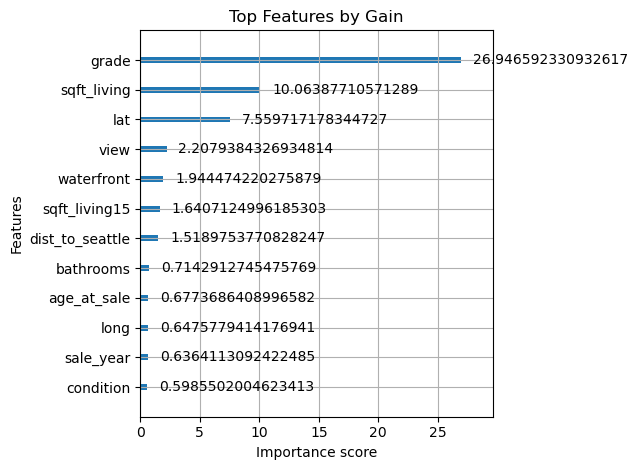

In [66]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plt.figure(figsize=(10, 8))
plot_importance(best_xgb_model, max_num_features=12, importance_type='gain')
plt.title('Top Features by Gain')
plt.tight_layout()
plt.show()